<a href="https://colab.research.google.com/github/chamm231305/CS4410-Machine-Learning/blob/main/Homework%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
from sklearn.datasets import load_diabetes

# Load dataset with features and target as a DataFrame
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,3.81e-02,0.05,0.06,2.19e-02,-4.42e-02,-0.03,-4.34e-02,-2.59e-03,1.99e-02,-1.76e-02,151.0
1,-1.88e-03,-0.04,-0.05,-2.63e-02,-8.45e-03,-0.02,7.44e-02,-3.95e-02,-6.83e-02,-9.22e-02,75.0
2,8.53e-02,0.05,0.04,-5.67e-03,-4.56e-02,-0.03,-3.24e-02,-2.59e-03,2.86e-03,-2.59e-02,141.0
3,-8.91e-02,-0.04,-0.01,-3.67e-02,1.22e-02,0.02,-3.60e-02,3.43e-02,2.27e-02,-9.36e-03,206.0
4,5.38e-03,-0.04,-0.04,2.19e-02,3.93e-03,0.02,8.14e-03,-2.59e-03,-3.20e-02,-4.66e-02,135.0


In [16]:
# Print dimensions and statistics
print("Dataset Shape:", df.shape)
pd.set_option("display.precision", 2)
df.describe()

Dataset Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.42e+02,4.42e+02,4.42e+02,4.42e+02,4.42e+02,4.42e+02,4.42e+02,4.42e+02,4.42e+02,4.42e+02,442.00
mean,-2.51e-19,1.23e-17,-2.25e-16,-4.80e-17,-1.38e-17,3.92e-17,-5.78e-18,-9.04e-18,9.29e-17,1.13e-17,152.13
std,4.76e-02,4.76e-02,4.76e-02,4.76e-02,4.76e-02,4.76e-02,4.76e-02,4.76e-02,4.76e-02,4.76e-02,77.09
min,-1.07e-01,-4.46e-02,-9.03e-02,-1.12e-01,-1.27e-01,-1.16e-01,-1.02e-01,-7.64e-02,-1.26e-01,-1.38e-01,25.00
25%,-3.73e-02,-4.46e-02,-3.42e-02,-3.67e-02,-3.42e-02,-3.04e-02,-3.51e-02,-3.95e-02,-3.32e-02,-3.32e-02,87.00
50%,5.38e-03,-4.46e-02,-7.28e-03,-5.67e-03,-4.32e-03,-3.82e-03,-6.58e-03,-2.59e-03,-1.95e-03,-1.08e-03,140.50
75%,3.81e-02,5.07e-02,3.12e-02,3.56e-02,2.84e-02,2.98e-02,2.93e-02,3.43e-02,3.24e-02,2.79e-02,211.50
max,1.11e-01,5.07e-02,1.71e-01,1.32e-01,1.54e-01,1.99e-01,1.81e-01,1.85e-01,1.34e-01,1.36e-01,346.00


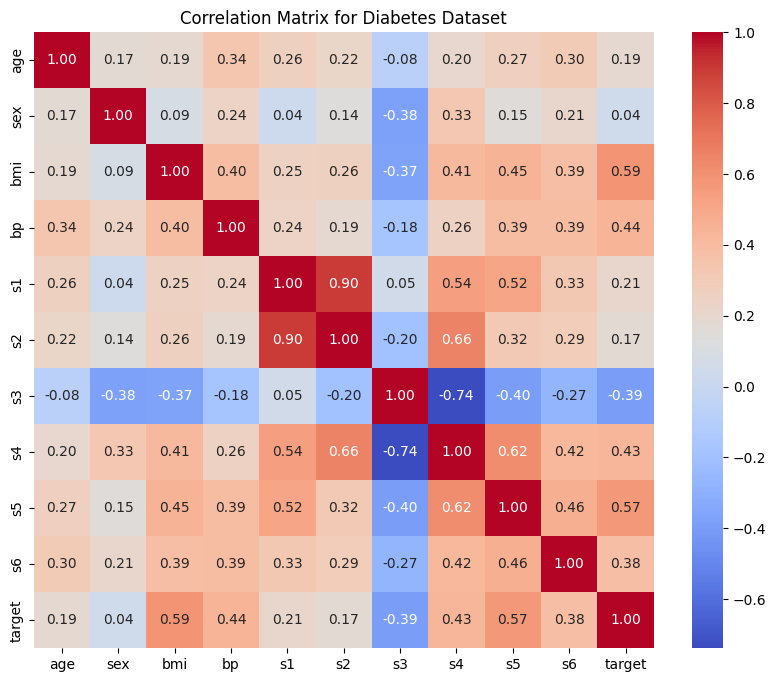

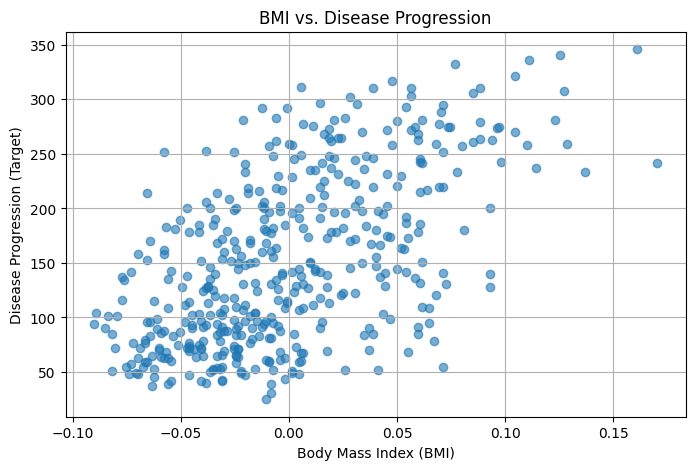

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Diabetes Dataset")
plt.show()

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df["bmi"], df["target"], alpha=0.6, color="tab:blue")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Disease Progression (Target)")
plt.title("BMI vs. Disease Progression")
plt.grid(True)
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (353, 10)
Testing set shape:  (89, 10)


In [19]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X=X_train, y=y_train)

print(f"Intercept: {linear_regression.intercept_:.2f}\n")
print("Coefficients:")
for feature, coef in zip(diabetes.feature_names, linear_regression.coef_):
    print(f"  {feature:>10s}: {coef:8.2f}")

Intercept: 151.35

Coefficients:
         age:    37.90
         sex:  -241.96
         bmi:   542.43
          bp:   347.70
          s1:  -931.49
          s2:   518.06
          s3:   163.42
          s4:   275.32
          s5:   736.20
          s6:    48.67


In [20]:
import numpy as np
from sklearn import metrics

predicted = linear_regression.predict(X_test)
expected = y_test

r2 = metrics.r2_score(expected, predicted)
mse = metrics.mean_squared_error(expected, predicted)
rmse = np.sqrt(mse)

print(f"R^2 Score:                        {r2:.4f}")
print(f"Mean Squared Error (MSE):         {mse:.2f}")
print(f"Root Mean Squared Error (RMSE):   {rmse:.2f}")

R^2 Score:                        0.4526
Mean Squared Error (MSE):         2900.19
Root Mean Squared Error (RMSE):   53.85


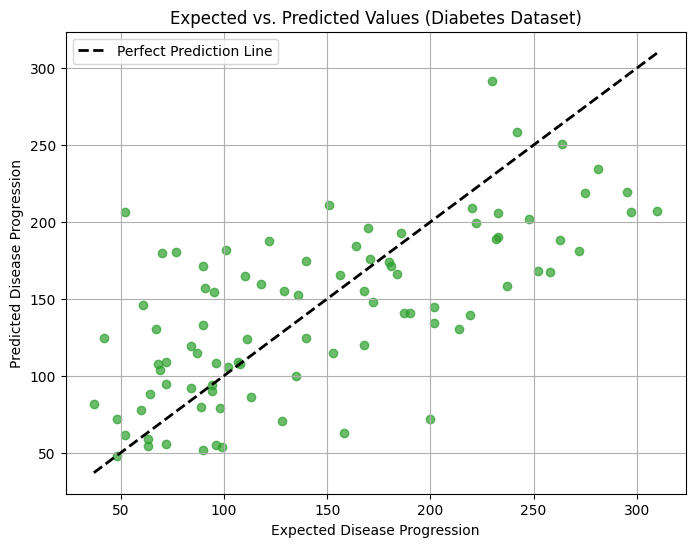

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(expected, predicted, alpha=0.7, color="tab:green")
plt.plot(
    [expected.min(), expected.max()],
    [expected.min(), expected.max()],
    "k--",
    lw=2,
    label="Perfect Prediction Line",
)

plt.xlabel("Expected Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Expected vs. Predicted Values (Diabetes Dataset)")
plt.legend()
plt.grid(True)
plt.show()